In [1]:
from CryogenicJanafPolynomials.thermoFit import ThermoFit
import matplotlib.pylab as plt
import numpy as np
import CoolProp.CoolProp as CP

# ============================================================================
#                   General Figure Settings
# ============================================================================

fSize = 20
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=fSize)
plt.rc('figure',figsize=[7,6])

lw = 3


# Polynomial coefficients of O2 from GRI Mech 3.0
CpCoeffsLow =  [3.78245636E+00, -2.99673416E-03,  9.84730201E-06, -9.68129509E-09,  3.24372837E-12, -1.06394356E+03, 3.65767573E+00]
CpCoeffsHigh = [3.28253784E+00,  1.48308754E-03, -7.57966669E-07,  2.09470555E-10, -2.16717794E-14, -1.08845772E+03, 5.45323129E+00]



Ru = 8.314          # Universal gas constant
M_O2 = 32.0/1000.0  # Molar mass of O2 [kg/mol]
R_O2 = Ru/M_O2      # Specific gas constant of O2 [J/kg/K]

def CpPoly(T,CpCoeffs):
    val = 0
    for i in range(5):
        val = val + CpCoeffs[i]*np.power(T,i)
    return val

def CpPolyDeriv(T,CpCoeffs):
    val = 0
    for i in range(4):
        val = val + CpCoeffs[i+1]*(i+1)*np.power(T,i)
    return val

def CpCoolProp(T,speciesName):
    Cp = np.zeros(T.shape)
    for i in range(len(T)):
        Cp[i] = CP.PropsSI('C','P|gas',0.1E+5,'T',T[i],speciesName)
    return Cp




# cryoFit = ThermoFit("O2",85,500,phase='gas',p=10000)
# highFit = ThermoFit("O2",500,3000,phase='gas',p=10000)

# plt.figure()
# ax = plt.gca()

# TLow = np.linspace(200,1000)
# plt.plot(TLow,CpPoly(TLow,CpCoeffsLow)*R_O2,label='GRI 3.0',color='tab:orange',lw=lw)
# plt.plot(TLow,CpCoolProp(TLow,"O2"),label='CoolProp',color='tab:blue',lw=lw)

# THigh = np.linspace(1000,3500)
# plt.plot(THigh,CpPoly(THigh,CpCoeffsHigh)*R_O2,color='tab:orange',lw=lw)
# plt.plot(THigh,CpCoolProp(THigh,"O2"),color='tab:blue',lw=lw)

# cryoFit.plot(ax,lw=lw,color='tab:green',ls='--',label='cryoFit')
# highFit.plot(ax,lw=lw,color='tab:red',label='highFit',ls='--')


# plt.xlabel('Temperature [K]')
# plt.ylabel(r'$C_p$ [J/kg/K]')
# plt.legend()
# plt.tight_layout()



# plt.figure()
# ax = plt.gca()

# TLow = np.linspace(200,1000)
# plt.plot(TLow,CpPoly(TLow,CpCoeffsLow)*R_O2,label='GRI 3.0',color='tab:orange',lw=lw)
# plt.plot(TLow,CpCoolProp(TLow,"O2"),label='CoolProp',color='tab:blue',lw=lw)
# cryoFit.plot(ax,lw=lw,color='tab:green',ls='--',label='cryoFit')

# plt.xlabel('Temperature [K]')
# plt.ylabel(r'$C_p$ [J/kg/K]')
# plt.legend()
# plt.tight_layout()
# plt.xlim([80,500])

# # Plot the derivative of the cryo fit
# # ===================================
# plt.figure()
# ax = plt.gca()
# TCryo = np.linspace(cryoFit.CpFit.domain[0],cryoFit.CpFit.domain[1],100)
# plt.plot(TCryo,CpPolyDeriv(TCryo,cryoFit.CpCoeffs))


(90.0, 200.0)

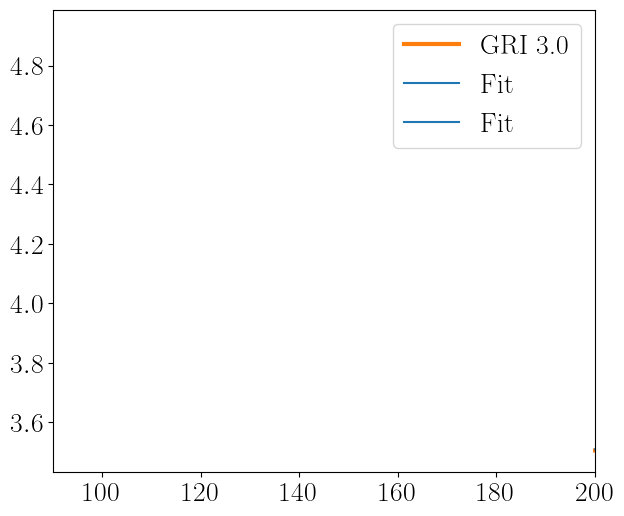

In [ ]:
from CryogenicJanafPolynomials.genCHEMKINThermo import GenCHEMKINThermo

thermoFile = GenCHEMKINThermo(90,800,3000,1E+4)
thermoFile.readChemkinFile('test/therm.dat')
thermoFile.genThermoData()
thermoFile.writeThermoFile()

plt.figure()
ax = plt.gca()

TLow = np.linspace(200,1000)
plt.plot(TLow,CpPoly(TLow,CpCoeffsLow),label='GRI 3.0',color='tab:orange',lw=lw)

THigh = np.linspace(1000,3500)
plt.plot(THigh,CpPoly(THigh,CpCoeffsHigh),color='tab:orange',lw=lw)

thermoFile.plot(ax,"O2","Cp",label="Fit")
plt.legend()
plt.xlim([90,200])

